# 🇻🇳 Transfer Learning — N-HiTS v1 → Vietnam Fine-tuning

**Chiến lược:** Load pretrained N-HiTS (từ 20 quốc gia) → Fine-tune trên dữ liệu Việt Nam.

- N-HiTS architecture không dùng Attention mà dùng MLP-based blocks.
- **Phase 1**: Freeze các block đầu tiên, chỉ train block cuối (tương tự như train head của TFT).
- **Phase 2**: Unfreeze tất cả, dùng Learning Rate nhỏ để tinh chỉnh toàn bộ mạng.


In [81]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — IMPORTS & PATHS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, os, json, pickle
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

from pytorch_forecasting import TimeSeriesDataSet, NHiTS
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MASE, MAE

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')

BASE_DIR  = Path('C:/Users/ADMIN/Downloads/MODEL_TFT')
DATA_PATH = BASE_DIR / 'data' / 'processed' / 'vn_data' / 'vn_tft_ready.csv'
PRETRAINED_DIR = BASE_DIR / 'checkpoint'

# Thông tin model pretrained
PRETRAIN_VER = 'nhits_v1'
PRETRAIN_CKPT = PRETRAINED_DIR / f'{PRETRAIN_VER}_best.ckpt'
PRETRAIN_CONF = PRETRAINED_DIR / f'{PRETRAIN_VER}_config.json'
PRETRAIN_DATA = PRETRAINED_DIR / f'{PRETRAIN_VER}_training_dataset.pkl'

# Thư mục lưu kết quả Transfer Learning
TL_CKPT_DIR = BASE_DIR / 'checkpoint'
TL_LOG_DIR  = BASE_DIR / 'lightning_logs' / 'nhits_vn_v1'
TL_CKPT_DIR.mkdir(exist_ok=True)
TL_LOG_DIR.mkdir(parents=True, exist_ok=True)


PyTorch  : 2.4.1+cpu
Device   : cpu


In [82]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — HYPERPARAMETERS (Điều chỉnh cho VN dataset)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
with open(PRETRAIN_CONF, 'r', encoding='utf-8') as f:
    pretrained_cfg = json.load(f)

CFG = dict(
    # Giữ nguyên cấu trúc sequence của pretrained
    max_encoder_length    = pretrained_cfg['max_encoder_length'],
    max_prediction_length = pretrained_cfg['max_prediction_length'],

    # N-HiTS Architecture
    n_blocks              = pretrained_cfg['n_blocks'],
    n_layers              = pretrained_cfg['n_layers'],
    hidden_size           = pretrained_cfg['hidden_size'],
    pooling_sizes         = pretrained_cfg['pooling_sizes'],
    downsample_frequencies= pretrained_cfg['downsample_frequencies'],
    dropout               = pretrained_cfg['dropout'],
    loss                  = pretrained_cfg['loss'],

    # Transfer Learning Training config
    batch_size            = 64,
    phase1_epochs         = 20,
    phase2_epochs         = 40,
    phase1_lr             = 1e-3,  # LR lớn để train nhanh block cuối
    phase2_lr             = 1e-4,  # LR nhỏ để tinh chỉnh toàn bộ mạng
    gradient_clip_val     = 0.1,
    patience              = 10,
    num_workers           = 0,
    val_cutoff_months     = 12,
    seed                  = 42,
)

pl.seed_everything(CFG['seed'], workers=True)
print('Config for Vietnam Transfer Learning:')
for k, v in CFG.items():
    print(f'  {k:<22}: {v}')


Seed set to 42


Config for Vietnam Transfer Learning:
  max_encoder_length    : 24
  max_prediction_length : 6
  n_blocks              : [1, 1, 1]
  n_layers              : 2
  hidden_size           : 512
  pooling_sizes         : [2, 2, 1]
  downsample_frequencies: [4, 2, 1]
  dropout               : 0.1
  loss                  : mase
  batch_size            : 64
  phase1_epochs         : 20
  phase2_epochs         : 40
  phase1_lr             : 0.001
  phase2_lr             : 0.0001
  gradient_clip_val     : 0.1
  patience              : 10
  num_workers           : 0
  val_cutoff_months     : 12
  seed                  : 42


In [83]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD & CHUẨN BỊ DATA VN
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

# Thêm cột entity (Vì N-HiTS dùng group_ids = ['entity', 'series'])
if 'entity' not in df.columns:
    df['entity'] = 'Vietnam'

# Đảm bảo target tên đúng
if 'generation_TWh' not in df.columns and 'generation_twh' in df.columns:
    df.rename(columns={'generation_twh': 'generation_TWh'}, inplace=True)

# 1. TRÁNH DATA LEAKAGE: Shift các feature thời tiết quan trắc
weather_cols = ['temperature', 'solar', 'humidity', 'precipitation', 'log_precipitation',
                'prec_zscore', 'temp_anomaly', 'solar_anomaly', 'temp_roc', 'precipitation_roc']

print('Shifting weather features (t-1)...')
for col in weather_cols:
    if col in df.columns:
        df[col] = df.groupby(['entity', 'series'])[col].shift(1)
        df[col] = df.groupby(['entity', 'series'])[col].transform(lambda x: x.fillna(0))

# 2. Tạo time_idx liên tục cho từng series
df = df.sort_values(['entity', 'series', 'date'])
df['time_idx'] = df.groupby(['entity', 'series'])['date'].rank(method='dense').astype(int) - 1

print(f'Shape dataset VN: {df.shape}')

# Train/Val Split
training_cutoff = int(df['time_idx'].max()) - CFG['val_cutoff_months']
val_cutoff_date = df['date'].max() - pd.DateOffset(months=CFG['val_cutoff_months'])

print(f'Train/Val Split:')
print(f'  training_cutoff (time_idx): {training_cutoff}')
print(f'  val_cutoff_date           : {val_cutoff_date.date()}')
print(f'  Train rows                : {(df["time_idx"] <= training_cutoff).sum():,}')
print(f'  Val rows                  : {(df["time_idx"] >  training_cutoff).sum():,}')


Shifting weather features (t-1)...
Shape dataset VN: (432, 30)
Train/Val Split:
  training_cutoff (time_idx): 59
  val_cutoff_date           : 2023-12-01
  Train rows                : 360
  Val rows                  : 72


In [84]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — TimeSeriesDataSet (VN dataset setup)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# N-HiTS dùng time_varying_known_reals cho các biến biết trước,
# và time_varying_unknown_reals cho các biến chưa biết (kể cả quá khứ target)

TIME_VARYING_KNOWN_REALS = [
    'time_idx', 'month', 'month_sin', 'month_cos', 'quarter', 'year',
    'is_dry_season', 'is_flood_season', 'quarter_sin', 'quarter_cos',
]

TIME_VARYING_UNKNOWN_REALS = [
    'generation_TWh',   # target
    'temperature', 'solar', 'humidity', 'precipitation', 'log_precipitation',
    'prec_zscore', 'temp_anomaly', 'solar_anomaly', 'temp_roc', 'precipitation_roc'
]

# Chỉ lấy các cột thực sự có trong data (để tránh lỗi nếu VN thiếu cột)
known_reals = [c for c in TIME_VARYING_KNOWN_REALS if c in df.columns]
unknown_reals = [c for c in TIME_VARYING_UNKNOWN_REALS if c in df.columns]

# Khởi tạo GroupNormalizer tương tự pretrain
target_normalizer = GroupNormalizer(
    groups         = ['entity', 'series'],
    transformation = 'softplus',
)

print('Creating TimeSeriesDataSet for VN...')
training_vn = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx                         = 'time_idx',
    target                           = 'generation_TWh',
    group_ids                        = ['entity', 'series'],
    min_encoder_length               = CFG['max_encoder_length'],
    max_encoder_length               = CFG['max_encoder_length'],
    min_prediction_length            = CFG['max_prediction_length'],
    max_prediction_length            = CFG['max_prediction_length'],
    static_categoricals              = ['entity'],
    static_reals                     = [],
    time_varying_known_categoricals  = ['series'],
    time_varying_known_reals         = known_reals,
    time_varying_unknown_categoricals= [],
    time_varying_unknown_reals       = unknown_reals,
    target_normalizer                = target_normalizer,
    add_relative_time_idx            = False,
    add_target_scales                = True,
    add_encoder_length               = True,
    allow_missing_timesteps          = True,
)
print(f'Training dataset (VN): {len(training_vn):,} samples')

validation_vn = TimeSeriesDataSet.from_dataset(
    training_vn, df, predict=True, stop_randomization=True
)
print(f'Validation dataset (VN): {len(validation_vn):,} samples')


Creating TimeSeriesDataSet for VN...
Training dataset (VN): 186 samples
Validation dataset (VN): 6 samples


In [85]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — DATALOADERS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
train_loader = training_vn.to_dataloader(
    train=True, batch_size=CFG['batch_size'], num_workers=CFG['num_workers'],
)
val_loader = validation_vn.to_dataloader(
    train=False, batch_size=CFG['batch_size']*2, num_workers=CFG['num_workers'],
)

x, y = next(iter(train_loader))
print('DataLoaders ready')
print(f'  Encoder shape: {x["encoder_cont"].shape}')
print(f'  Decoder shape: {x["decoder_cont"].shape}')
print(f'  Target shape : {y[0].shape}')


DataLoaders ready
  Encoder shape: torch.Size([64, 24, 11])
  Decoder shape: torch.Size([64, 6, 11])
  Target shape : torch.Size([64, 6])


In [86]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — TẠO MODEL N-HiTS CHO VN & COPY PRETRAINED WEIGHTS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Chọn loss function
if CFG['loss'] == 'mase':
    loss_fn = MASE()
else:
    loss_fn = MAE()

# 1. Khởi tạo model mới từ config VN dataset (Có thể input size sẽ khác pretrain vì thêm features)
vn_model = NHiTS.from_dataset(
    training_vn,
    n_blocks              = CFG['n_blocks'],
    n_layers              = CFG['n_layers'],
    hidden_size           = CFG['hidden_size'],
    pooling_sizes         = CFG['pooling_sizes'],
    downsample_frequencies= CFG['downsample_frequencies'],
    dropout               = CFG['dropout'],
    loss                  = loss_fn,
    learning_rate         = CFG['phase1_lr'],
    optimizer             = 'adam',
    log_interval          = 5,
    log_val_interval      = 1,
)

n_params_vn = sum(p.numel() for p in vn_model.parameters() if p.requires_grad)
print(f'VN model parameters: {n_params_vn:,} ({n_params_vn/1e6:.2f}M)')

# 2. Load Pretrained weights
print(f'\nLoading pretrained weights from: {PRETRAIN_CKPT.name}')
pretrained_model = NHiTS.load_from_checkpoint(str(PRETRAIN_CKPT))

# Lọc bỏ các weights bị sai kích thước (size mismatch) do số lượng entity/series/features khác nhau
pretrained_state_dict = pretrained_model.state_dict()
vn_state_dict = vn_model.state_dict()

filtered_state_dict = {}
skipped_layers = []

for name, param in pretrained_state_dict.items():
    if name in vn_state_dict:
        if vn_state_dict[name].shape == param.shape:
            filtered_state_dict[name] = param
        else:
            skipped_layers.append(f"{name} (mismatch: {list(param.shape)} vs {list(vn_state_dict[name].shape)})")

missing, unexpected = vn_model.load_state_dict(filtered_state_dict, strict=False)

print(f'\nLayers skipped (sẽ train từ đầu do khác size):')
for m in skipped_layers:
    print(f'  - {m}')

if missing:
    print(f'\nCác layers mới thêm vào VN model (train từ đầu):')
    for m in missing:
        if 'weight' in m or 'bias' in m:
            print(f'  - {m}')

print('\n✅ Pretrained weights transferred (partial) successfully.')


VN model parameters: 2,120,299 (2.12M)

Loading pretrained weights from: nhits_v1_best.ckpt

Layers skipped (sẽ train từ đầu do khác size):
  - embeddings.embeddings.entity.weight (mismatch: [20, 9] vs [1, 1])
  - embeddings.embeddings.series.weight (mismatch: [9, 5] vs [6, 4])
  - model.blocks.0.static_encoder.encoder.1.weight (mismatch: [512, 12] vs [512, 4])
  - model.blocks.0.layers.layers.0.weight (mismatch: [512, 950] vs [512, 830])
  - model.blocks.1.static_encoder.encoder.1.weight (mismatch: [512, 12] vs [512, 4])
  - model.blocks.1.layers.layers.0.weight (mismatch: [512, 950] vs [512, 830])
  - model.blocks.2.static_encoder.encoder.1.weight (mismatch: [512, 12] vs [512, 4])
  - model.blocks.2.layers.layers.0.weight (mismatch: [512, 962] vs [512, 842])

Các layers mới thêm vào VN model (train từ đầu):
  - embeddings.embeddings.entity.weight
  - embeddings.embeddings.series.weight
  - model.blocks.0.static_encoder.encoder.1.weight
  - model.blocks.0.layers.layers.0.weight
  - mo

In [87]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — PHASE 1: FREEZE N-1 BLOCKS ĐẦU TIÊN, CHỈ TRAIN BLOCK CUỐI
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def freeze_nhits_blocks(model, blocks_to_freeze):
    """Đóng băng các block cụ thể của N-HiTS."""
    frozen = []
    for name, param in model.named_parameters():
        for i in range(blocks_to_freeze):
            if f'blocks.{i}.' in name:
                param.requires_grad = False
                frozen.append(name)
    return frozen

def unfreeze_all(model):
    """Unfreeze tất cả parameters."""
    for param in model.parameters():
        param.requires_grad = True

# Freeze các block đầu tiên (giữ lại block cuối để train nhanh)
n_blocks_total = len(CFG['n_blocks'])
blocks_to_freeze = max(1, n_blocks_total - 1)  # Nếu có 3 stack, freeze 2 stack đầu

frozen_layers = freeze_nhits_blocks(vn_model, blocks_to_freeze)

trainable_p1 = sum(p.numel() for p in vn_model.parameters() if p.requires_grad)
print(f'Phase 1: Train {trainable_p1:,} params / Total {n_params_vn:,} params')
print(f'Đã đóng băng {len(frozen_layers)} parameter tensors (thuộc {blocks_to_freeze} stack đầu).')

# Callbacks Phase 1
ckpt_cb_p1 = ModelCheckpoint(
    dirpath=str(TL_CKPT_DIR), filename='vn_nhits_phase1_{epoch:02d}_{val_loss:.4f}',
    monitor='val_loss', mode='min', save_top_k=1, verbose=False
)
early_stop_p1 = EarlyStopping(monitor='val_loss', patience=CFG['patience'], min_delta=1e-4, mode='min')
logger_p1 = TensorBoardLogger(save_dir=str(BASE_DIR/'lightning_logs'), name='nhits_vn_phase1')

trainer_p1 = pl.Trainer(
    accelerator='gpu' if DEVICE == 'cuda' else 'cpu', devices=1,
    max_epochs=CFG['phase1_epochs'], gradient_clip_val=CFG['gradient_clip_val'],
    callbacks=[ckpt_cb_p1, early_stop_p1], logger=logger_p1,
    enable_progress_bar=True, enable_model_summary=False,
)

print('\nBẮT ĐẦU TRAINING PHASE 1 (FROZEN BACKBONE) - N-HiTS')
trainer_p1.fit(vn_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
print(f'Phase 1 done! Best val_loss = {float(ckpt_cb_p1.best_model_score):.6f}')


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Phase 1: Train 712,247 params / Total 2,120,299 params
Đã đóng băng 16 parameter tensors (thuộc 2 stack đầu).

BẮT ĐẦU TRAINING PHASE 1 (FROZEN BACKBONE) - N-HiTS


Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


Phase 1 done! Best val_loss = 0.521649


In [88]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — PHASE 2: UNFREEZE + FULL FINE-TUNE VỚI LR NHỎ
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Load best model từ Phase 1
best_phase1_path = ckpt_cb_p1.best_model_path
if os.path.exists(best_phase1_path):
    print(f'Loading best Phase 1 model: {Path(best_phase1_path).name}')
    vn_model = NHiTS.load_from_checkpoint(best_phase1_path)

# Unfreeze toàn bộ
unfreeze_all(vn_model)

# Chỉnh learning rate nhỏ hơn cho Phase 2
vn_model.hparams.learning_rate = CFG['phase2_lr']
trainable_p2 = sum(p.numel() for p in vn_model.parameters() if p.requires_grad)
print(f'Phase 2: Train FULL {trainable_p2:,} params (Learning Rate: {CFG["phase2_lr"]})')

# Callbacks Phase 2
ckpt_cb_p2 = ModelCheckpoint(
    dirpath=str(TL_CKPT_DIR), filename='vn_nhits_phase2_{epoch:02d}_{val_loss:.4f}',
    monitor='val_loss', mode='min', save_top_k=2, verbose=True
)
early_stop_p2 = EarlyStopping(monitor='val_loss', patience=CFG['patience'], min_delta=1e-4, mode='min')
logger_p2 = TensorBoardLogger(save_dir=str(BASE_DIR/'lightning_logs'), name='nhits_vn_phase2')

trainer_p2 = pl.Trainer(
    accelerator='gpu' if DEVICE == 'cuda' else 'cpu', devices=1,
    max_epochs=CFG['phase2_epochs'], gradient_clip_val=CFG['gradient_clip_val'],
    callbacks=[ckpt_cb_p2, early_stop_p2, LearningRateMonitor()], logger=logger_p2,
    enable_progress_bar=True, enable_model_summary=False,
)

print('\nBẮT ĐẦU TRAINING PHASE 2 (FULL FINE-TUNE) - N-HiTS')
trainer_p2.fit(vn_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
print(f'Phase 2 done! Best val_loss = {float(ckpt_cb_p2.best_model_score):.6f}')


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Loading best Phase 1 model: vn_nhits_phase1_epoch=17_val_loss=0.5216-v3.ckpt
Phase 2: Train FULL 2,120,299 params (Learning Rate: 0.0001)

BẮT ĐẦU TRAINING PHASE 2 (FULL FINE-TUNE) - N-HiTS


Output()

Epoch 0, global step 2: 'val_loss' reached 0.56387 (best 0.56387), saving model to 'C:\\Users\\ADMIN\\Downloads\\MODEL_TFT\\checkpoint\\vn_nhits_phase2_epoch=00_val_loss=0.5639.ckpt' as top 2


Epoch 1, global step 4: 'val_loss' reached 0.58271 (best 0.56387), saving model to 'C:\\Users\\ADMIN\\Downloads\\MODEL_TFT\\checkpoint\\vn_nhits_phase2_epoch=01_val_loss=0.5827.ckpt' as top 2


...

Epoch 15, global step 32: 'val_loss' was not in top 2


Epoch 16, global step 34: 'val_loss' was not in top 2


Epoch 17, global step 36: 'val_loss' was not in top 2


Epoch 18, global step 38: 'val_loss' was not in top 2


Phase 2 done! Best val_loss = 0.523402


In [89]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — LƯU CHECKPOINT CUỐI & CONFIG
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import shutil

BEST_TL_CKPT = TL_CKPT_DIR / 'nhits_vn_v3_best.ckpt'
if os.path.exists(ckpt_cb_p2.best_model_path):
    shutil.copy2(ckpt_cb_p2.best_model_path, BEST_TL_CKPT)
    print(f'✅ Đã lưu best fine-tuned checkpoint: {BEST_TL_CKPT}')

tl_config = {
    'version'                : 'nhits_vn_v3',
    'base_model'             : PRETRAIN_CKPT.name,
    'best_ckpt'              : str(BEST_TL_CKPT),
    'phase1_val_loss'        : float(ckpt_cb_p1.best_model_score),
    'phase2_val_loss'        : float(ckpt_cb_p2.best_model_score),
    'max_encoder_length'     : CFG['max_encoder_length'],
    'max_prediction_length'  : CFG['max_prediction_length'],
    'n_blocks'               : CFG['n_blocks'],
    'hidden_size'            : CFG['hidden_size'],
}

conf_path = TL_CKPT_DIR / 'nhits_vn_v3_config.json'
with open(conf_path, 'w', encoding='utf-8') as f:
    json.dump(tl_config, f, indent=2, ensure_ascii=False)
print(f'✅ Đã lưu config: {conf_path}')


✅ Đã lưu best fine-tuned checkpoint: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\nhits_vn_v3_best.ckpt
✅ Đã lưu config: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\nhits_vn_v3_config.json


In [90]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — EVALUATION: METRICS TỔNG QUÁT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
best_model = NHiTS.load_from_checkpoint(str(BEST_TL_CKPT))
best_model.eval()
print(f'Best N-HiTS Fine-tuned model loaded.')

# Dự đoán (Sử dụng prediction / median)
raw_preds = best_model.predict(val_loader, mode='prediction', return_x=True)
pred_vals = raw_preds.output
x_vals    = raw_preds.x

# Lấy ground truth
actuals = torch.cat([y[0] for _, y in val_loader])

# Tính toán các metric
mae   = (actuals - pred_vals).abs().mean().item()
rmse  = ((actuals - pred_vals) ** 2).mean().sqrt().item()
smape = (2 * (actuals - pred_vals).abs() / (actuals.abs() + pred_vals.abs() + 1e-8)).mean().item() * 100
wape  = (actuals - pred_vals).abs().sum().item() / (actuals.abs().sum().item() + 1e-8) * 100

print('╔══════════════════════════════════════════════════════════════╗')
print('║                 KẾT QUẢ FINE-TUNING (N-HiTS)                 ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Phase 1 val_loss : {float(ckpt_cb_p1.best_model_score):.6f} (frozen blocks)              ║')
print(f'║  Phase 2 val_loss : {float(ckpt_cb_p2.best_model_score):.6f} (full tune)                  ║')
print(f'║  MAE              : {mae:.4f} TWh                                ║')
print(f'║  RMSE             : {rmse:.4f} TWh                               ║')
print(f'║  SMAPE            : {smape:.2f}%                                  ║')
print(f'║  WAPE             : {wape:.2f}%                                   ║')
print('╚══════════════════════════════════════════════════════════════╝')


Best N-HiTS Fine-tuned model loaded.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


╔══════════════════════════════════════════════════════════════╗
║                 KẾT QUẢ FINE-TUNING (N-HiTS)                 ║
╠══════════════════════════════════════════════════════════════╣
║  Phase 1 val_loss : 0.521649 (frozen blocks)              ║
║  Phase 2 val_loss : 0.523402 (full tune)                  ║
║  MAE              : 0.5639 TWh                                ║
║  RMSE             : 0.9574 TWh                               ║
║  SMAPE            : 11.91%                                  ║
║  WAPE             : 12.68%                                   ║
╚══════════════════════════════════════════════════════════════╝


In [91]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — METRICS THEO TỪNG SERIES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
series_names = [training_vn.target_normalizer.groups[1]] if isinstance(training_vn.target_normalizer.groups, list) else ['series']

# Decode series indices
val_groups = [batch[0]['decoder_cat'][:, 0, 1].cpu().numpy() for batch in val_loader]
val_groups = np.concatenate(val_groups)

# Ánh xạ từ index về tên chuỗi (ví dụ: 'Coal', 'Gas')
cat_map = validation_vn.categorical_encoders['series'].classes_
idx_to_class = {v: k for k, v in cat_map.items()}

series_metrics = []
for i, s_idx in enumerate(np.unique(val_groups)):
    mask = val_groups == s_idx
    s_name = idx_to_class[s_idx]

    act_s = actuals[mask]
    prd_s = pred_vals[mask]

    s_mae = (act_s - prd_s).abs().mean().item()
    s_rmse = ((act_s - prd_s) ** 2).mean().sqrt().item()
    s_wape = (act_s - prd_s).abs().sum().item() / (act_s.abs().sum().item() + 1e-8) * 100

    series_metrics.append({
        'Series': s_name, 'MAE': s_mae, 'RMSE': s_rmse, 'WAPE (%)': s_wape
    })

df_metrics = pd.DataFrame(series_metrics).set_index('Series').sort_values('WAPE (%)')
print("METRICS TỪNG NGUỒN ĐIỆN:")
display(df_metrics.style.format('{:.4f}', subset=['MAE', 'RMSE']).format('{:.2f}', subset=['WAPE (%)']).background_gradient(cmap='Blues'))


METRICS TỪNG NGUỒN ĐIỆN:


,MAE,RMSE,WAPE (%)
Series,,,
Other fossil,0.0000,0.0000,0.00
Solar,0.1214,0.1560,5.46
Hydro,1.2189,1.5974,10.52
Coal,1.4262,1.5555,13.94
Wind,0.1540,0.2370,16.71
Gas,0.4627,0.6694,26.82


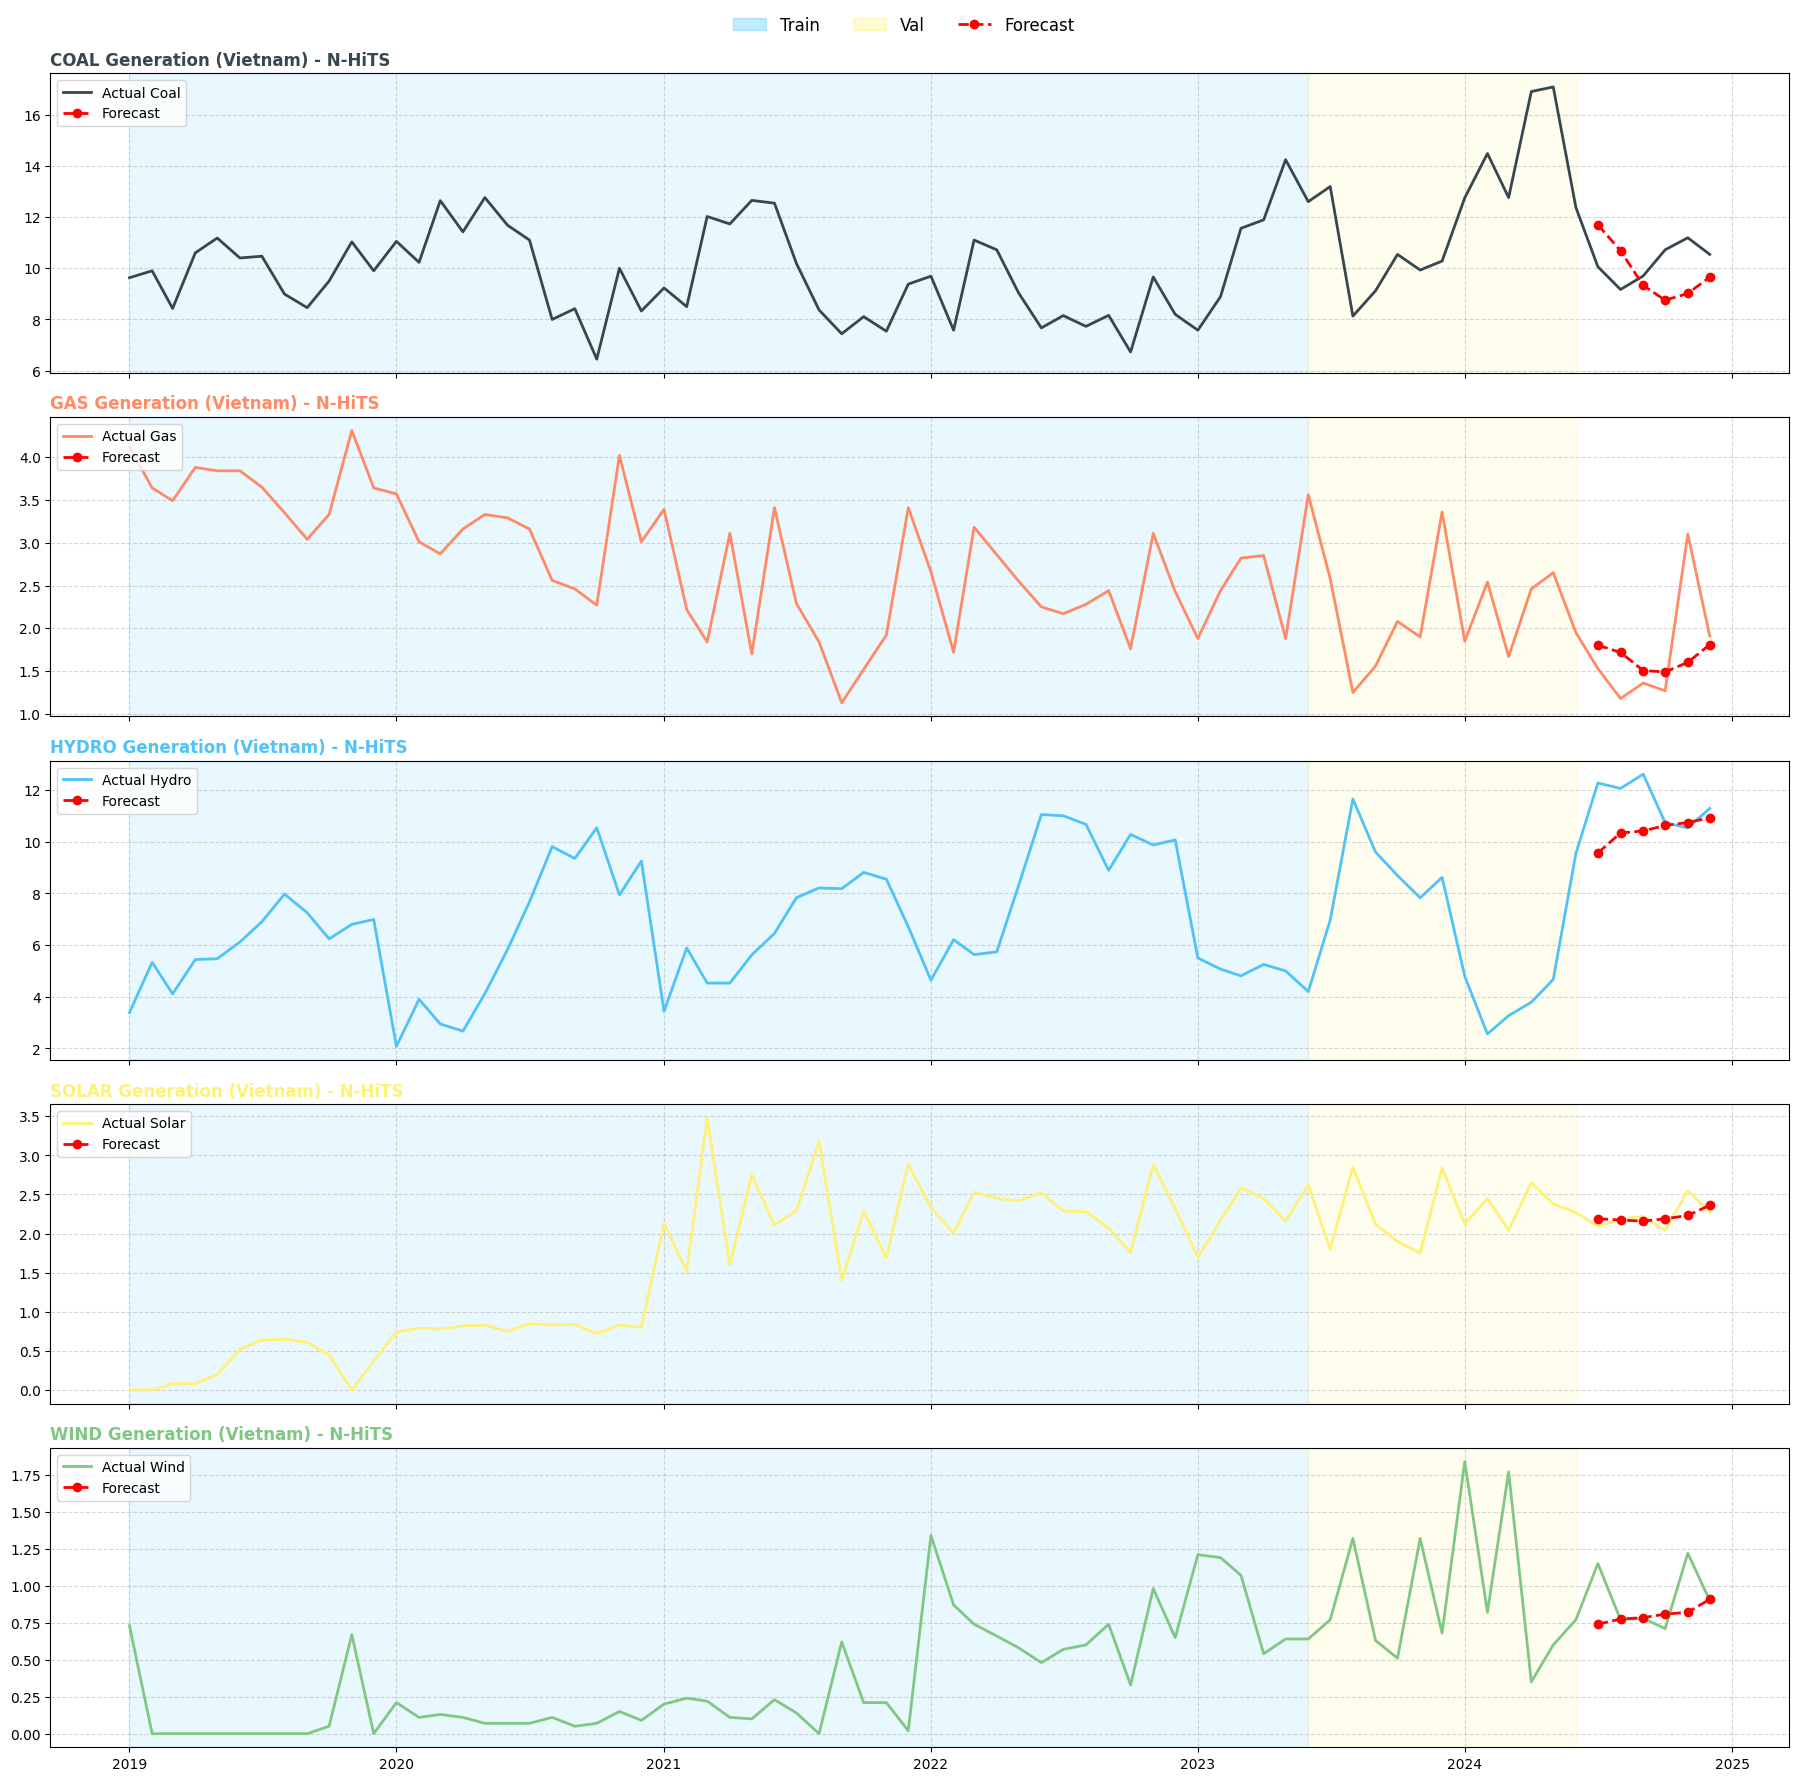

In [94]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 — VISUALIZE PREDICTIONS PER SERIES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SERIES_COLORS = {
    'Coal': '#37474F', 'Gas': '#FF8A65', 'Hydro': '#4FC3F7', 'Solar': '#FFF176',
    'Wind': '#81C784', 'Bioenergy': '#AED581', 'Nuclear': '#9575CD',
    'Other Fossil': '#A1887F', 'Other Renewables': '#4DB6AC'
}

FINE_TUNE_SERIES = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']

TRAIN_END = pd.Timestamp('2023-06-01')
VAL_END   = pd.Timestamp('2024-06-01')

fig, axes = plt.subplots(len(FINE_TUNE_SERIES), 1, figsize=(18, 3.5 * len(FINE_TUNE_SERIES)), sharex=True)

for ax, ser in zip(axes, FINE_TUNE_SERIES):
    sub   = df[df['series'] == ser].sort_values('date')
    color = SERIES_COLORS.get(ser, '#aaa')

    # Biểu đồ gốc
    ax.plot(sub['date'], sub['generation_TWh'], color=color, linewidth=2, label=f'Actual {ser}')

    # Vùng background Train / Val
    ax.axvspan(sub['date'].min(), TRAIN_END, alpha=0.12, color='#4fc3f7', label='_nolegend_')
    ax.axvspan(TRAIN_END, VAL_END, alpha=0.12, color='#fff176', label='_nolegend_')

    # Lấy các điểm dự đoán của series này
    s_idx = cat_map[ser]
    ser_mask = val_groups == s_idx
    if ser_mask.sum() > 0:
        # Lấy sample dự đoán xa nhất
        idx_in_val = np.where(ser_mask)[0][-1]

        # Plot prediction
        time_idxs = validation_vn.decoded_index.iloc[idx_in_val]['time_idx_first_prediction'] - 1
        last_date = sub[sub['time_idx'] == time_idxs]['date'].iloc[0]

        pred_dates = [last_date + pd.DateOffset(months=i+1) for i in range(CFG['max_prediction_length'])]
        pred_line = pred_vals[idx_in_val].cpu().numpy()

        ax.plot(pred_dates, pred_line, color='red', linestyle='--', marker='o', linewidth=2, label='Forecast')

    ax.set_title(f'{ser.upper()} Generation (Vietnam) - N-HiTS', loc='left', fontweight='bold', color=color)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

custom_patches = [
    mpatches.Patch(color='#4fc3f7', alpha=0.35, label='Train'),
    mpatches.Patch(color='#fff176', alpha=0.35, label='Val'),
    plt.Line2D([0], [0], color='red', linestyle='--', marker='o', lw=2, label='Forecast')
]
fig.legend(handles=custom_patches, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig(str(TL_CKPT_DIR / 'nhits_vn_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()
